# MMoE Model voor Rister Planning

## Wat doet dit notebook?

Dit notebook traint een **MMoE (Multi-gate Mixture of Experts)** model voor twee taken tegelijk:

1. **Tijdsvoorspelling** — Hoeveel uur kost een servicetaak?
2. **Medewerker ranking** — Welke medewerker is het meest geschikt voor een taak?

## Waarom MMoE en niet twee aparte modellen?

Tijdsduur en geschiktheid hangen samen. Een snelle medewerker heeft vaak een lage tijdscore, maar een hoge geschiktheidsscore voor efficiënte klanten. Door beide taken samen te trainen deelt het model kennis — dat geeft betere voorspellingen dan twee losse modellen.

## Hoe werkt MMoE?

```
Input features
      │
      ├──► [Expert 1]─┐
      ├──► [Expert 2]─┤
      ├──► [Expert 3]─┤
      └──► [Expert N]─┘
                      │
           ┌──────────┤──────────┐
      [Gate Tijd]          [Gate Ranking]
      (wegingen)           (wegingen)
           │                    │
    [Tower Tijd]         [Tower Ranking]
           │                    │
    time_prediction      suitability_score
```

**Experts** zijn kleine neurale netwerken die elk een eigen representatie van de data leren. **Gates** leren per taak welke experts het meest relevant zijn. **Towers** maken de uiteindelijke voorspelling per taak.

## Overzicht notebook

| Stap | Wat |
|------|-----|
| 1-3 | Installatie, imports, MLflow |
| 4-5 | Data laden en feature definitie |
| 6-7 | Data voorbereiden en verkennen |
| 8-9 | Dataset, MMoE architectuur |
| 10-12 | Loss, Optuna tuning, volledig trainen |
| 13-16 | Evaluatie, feature importance |
| 17-19 | Fine-tuning, inference |
| 20-22 | Opslaan, ONNX export, MLflow |

## Stap 1: Packages installeren

- **torch** — PyTorch, het deep learning framework voor het MMoE model
- **optuna** — Automatische hyperparameter-zoeker
- **onnx / onnxruntime** — Exportformaat voor de C# API
- **mlflow** — Bijhouden van trainingsresultaten
- **scikit-learn** — Data preprocessing en evaluatiemetrics

In [84]:
!pip install torch optuna onnx onnxruntime mlflow scikit-learn --quiet

## Stap 2: Imports

We laden alle benodigde libraries en kiezen het beste beschikbare apparaat voor training:
- **MPS** — Apple Silicon GPU (Mac M1/M2/M4), snelste optie op Mac
- **CUDA** — NVIDIA GPU
- **CPU** — Altijd beschikbaar, maar langzamer

In [85]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    ndcg_score,
)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pickle
import os
import json
import mlflow

# Apparaat kiezen: MPS (Mac) > CUDA (NVIDIA) > CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"PyTorch versie     : {torch.__version__}")
print(f"Trainingsapparaat  : {DEVICE}")

PyTorch versie     : 2.10.0
Trainingsapparaat  : mps


## Stap 3: MLflow configuratie

**MLflow** houdt bij welke parameters en resultaten we gebruiken bij elke trainingsrun. Start MLflow met `mlflow ui` in je terminal en open `http://127.0.0.1:5000` in je browser om resultaten te vergelijken.

In [86]:
MLFLOW_TRACKING_URI = "http://127.0.0.1:5001"
MLFLOW_EXPERIMENT = "rister-mmoe-v1"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f"MLflow experiment : {MLFLOW_EXPERIMENT}")
print(f"MLflow UI         : {MLFLOW_TRACKING_URI}")

MLflow experiment : rister-mmoe-v1
MLflow UI         : http://127.0.0.1:5001


## Stap 4: Data laden

We lezen de gecombineerde CSV in. Elke rij is één historisch servicebezoek met info over de taak, medewerker, klant en werkelijk bestede tijd.

In [87]:
df = pd.read_csv("dataframe_gecombineerd.csv")
# Fix kolomnaam mismatch: CSV gebruikt 'aar' prefix
df.rename(columns={"aarURENVERANTW_MEDID": "URENVERANTW_MEDID"}, inplace=True)
print(f"Rijen: {len(df):,}  |  Kolommen: {len(df.columns)}")
df.head()

/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_42602/1114684966.py:1: DtypeWarning: Columns (0,1,3,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dataframe_gecombineerd.csv')


Rijen: 333,994  |  Kolommen: 41


,URENVERANTW_MEDID,DIENST_ART_ID,BEWERKING_ID,RELATIE_ID,DIENST_ART_OMS,MACH_OMS,REL_POSTCODE,lat,lon,URENVERANTW_DATUM,...,hoeveelheid_aanwezig,con,REAL_WORKED_TIME,bron,EquipmentGroupTypes,planninggroupsname,hoeveelheid_baal,norm_ervaring_bewerking,norm_klant_bezoeken,suitability_score
0,25,1725,NaN,4144.0,Rupskraan 7-ton derden,NaN,2355AH,52.168026,4.580257,2015-01-16,...,0.0,15_poel,9.0,werkxpert,NaN,NaN,NaN,0.000000,0.000000,0.000000
1,753,1620,NaN,4266.0,Mob. kraan JCB JS 175,NaN,2841BJ,51.986980,4.673187,2015-01-16,...,0.0,15_poel,9.0,werkxpert,NaN,NaN,NaN,0.000000,0.000000,0.000000
2,25,1634,NaN,4144.0,Aanvoer kranen (derden),NaN,2355AH,52.168026,4.580257,2015-01-16,...,1.0,15_poel,9.0,werkxpert,NaN,NaN,NaN,0.000000,0.030303,0.012121
3,32,1195,NaN,4266.0,Man + gereedschap aannemers,NaN,2841BJ,51.986980,4.673187,2015-01-16,...,0.0,15_poel,9.0,werkxpert,NaN,NaN,NaN,0.000000,0.000000,0.000000
4,753,1620,NaN,4266.0,Mob. kraan JCB JS 175,NaN,2841BJ,51.986980,4.673187,2015-01-17,...,0.0,15_poel,6.5,werkxpert,NaN,NaN,NaN,0.001621,0.030303,0.013094


## Stap 5: Feature definitie

**Categorische features** — labels zoals medewerker-ID, type dienst of postcode. Het model leert een numerieke vector (embedding) per categorie.

**Numerieke features** — gewone getallen zoals coördinaten, tijdgemiddelden en hoeveelheden.

**Targets** (wat we voorspellen):
- `REAL_WORKED_TIME` — werkelijke duur in uren
- `suitability_score` — geschiktheid medewerker (0.0 – 1.0)

In [88]:
CATEGORICAL = [
    "URENVERANTW_MEDID",
    "BEWERKING_ID",
    "DIENST_ART_ID",
    "RELATIE_ID",
    "REL_POSTCODE",
    "DIENST_ART_OMS",
    "MACH_OMS",
    "con",
    "bron",
    "EquipmentGroupTypes",
    "planninggroupsname",
]

NUMERICAL = [
    "lat",
    "lon",
    "dag_sin",
    "dag_cos",
    "maand_sin",
    "maand_cos",
    "week_sin",
    "week_cos",
    "med_std_tijd",
    "med_aantal_opdrachten",
    "med_ervaring_bewerking",
    "med_gem_tijd",
    "taak_gem",
    "med_klant_bezoeken",
    "med_klant_ratio",
    "med_klant_snelheid",
    "med_bewerking_snelheid",
    "med_klant_gem_tijd",
    "med_bewerking_gem_tijd",
    "med_totaal_opdrachten",
    "hoeveelheid_volume",
    "hoeveelheid_gewicht",
    "hoeveelheid_stuks",
    "hoeveelheid_aanwezig",
    "hoeveelheid_baal",
]

TARGET_TIME = "REAL_WORKED_TIME"
TARGET_RANK = "suitability_score"

print(f"Categorische features : {len(CATEGORICAL)}")
print(f"Numerieke features    : {len(NUMERICAL)}")
print(f"Totaal input features : {len(CATEGORICAL) + len(NUMERICAL)}")

Categorische features : 11
Numerieke features    : 25
Totaal input features : 36


## Stap 6: Data voorbereiden

Neurale netwerken werken alleen met getallen. We moeten:

1. **Categorische kolommen encoderen** — elk uniek label krijgt een integer via `LabelEncoder`
2. **Numerieke kolommen normaliseren** — `StandardScaler` schaalt alles naar gemiddelde 0 en std 1, zodat grote getallen geen oneerlijk voordeel krijgen
3. **Target log-transformeren** — werktijden zijn sterk scheefverdeeld (veel kort, weinig heel lang). `log1p(x)` maakt die verdeling vlakker en stabieler voor training

In [89]:
# Categorische kolommen: lege waardes vullen + integer codering
label_encoders = {}
cat_cardinalities = {}

for col in CATEGORICAL:
    df[col] = df[col].fillna("ONBEKEND").astype(str)
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    label_encoders[col] = le
    cat_cardinalities[col] = len(le.classes_)

print("Categorische cardinaliteiten (= grootte embedding tabel):")
for col, card in cat_cardinalities.items():
    print(f"  {col:30s} -> {card:5d} unieke waardes")

Categorische cardinaliteiten (= grootte embedding tabel):
  URENVERANTW_MEDID              ->   878 unieke waardes
  BEWERKING_ID                   ->   270 unieke waardes
  DIENST_ART_ID                  ->  2125 unieke waardes
  RELATIE_ID                     ->  6196 unieke waardes
  REL_POSTCODE                   ->  3756 unieke waardes
  DIENST_ART_OMS                 ->  2251 unieke waardes
  MACH_OMS                       ->   808 unieke waardes
  con                            ->    77 unieke waardes
  bron                           ->     2 unieke waardes
  EquipmentGroupTypes            ->     4 unieke waardes
  planninggroupsname             ->   114 unieke waardes


### Numerieke features normaliseren
Alle getallen schalen naar gemiddelde 0 en standaarddeviatie 1 met `StandardScaler`.

In [90]:
for col in NUMERICAL:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

scaler = StandardScaler()
df_num_scaled = scaler.fit_transform(df[NUMERICAL])
print("Numerieke kolommen genormaliseerd (gemiddelde=0, std=1)")

Numerieke kolommen genormaliseerd (gemiddelde=0, std=1)


### Target log-transformeren
`log1p(x)` maakt de scheefverdeelde werktijden vlakker. Bij evaluatie rekenen we terug met `expm1(y)`.

In [91]:
df["time_log"] = np.log1p(df[TARGET_TIME].clip(lower=0))
print(f"Target 'time_log' aangemaakt via log1p({TARGET_TIME})")

Target 'time_log' aangemaakt via log1p(REAL_WORKED_TIME)


## Stap 7: Data verkennen

Voordat we trainen kijken we naar de verdeling van beide targets. Dit helpt begrijpen:
- Hoe scheef is de tijdsverdeling (en waarom log-transformatie nodig is)?
- Hoe verdeeld zijn de geschiktheidsscores?
- Is er correlatie tussen de twee? (Lage correlatie = MMoE is extra nuttig)

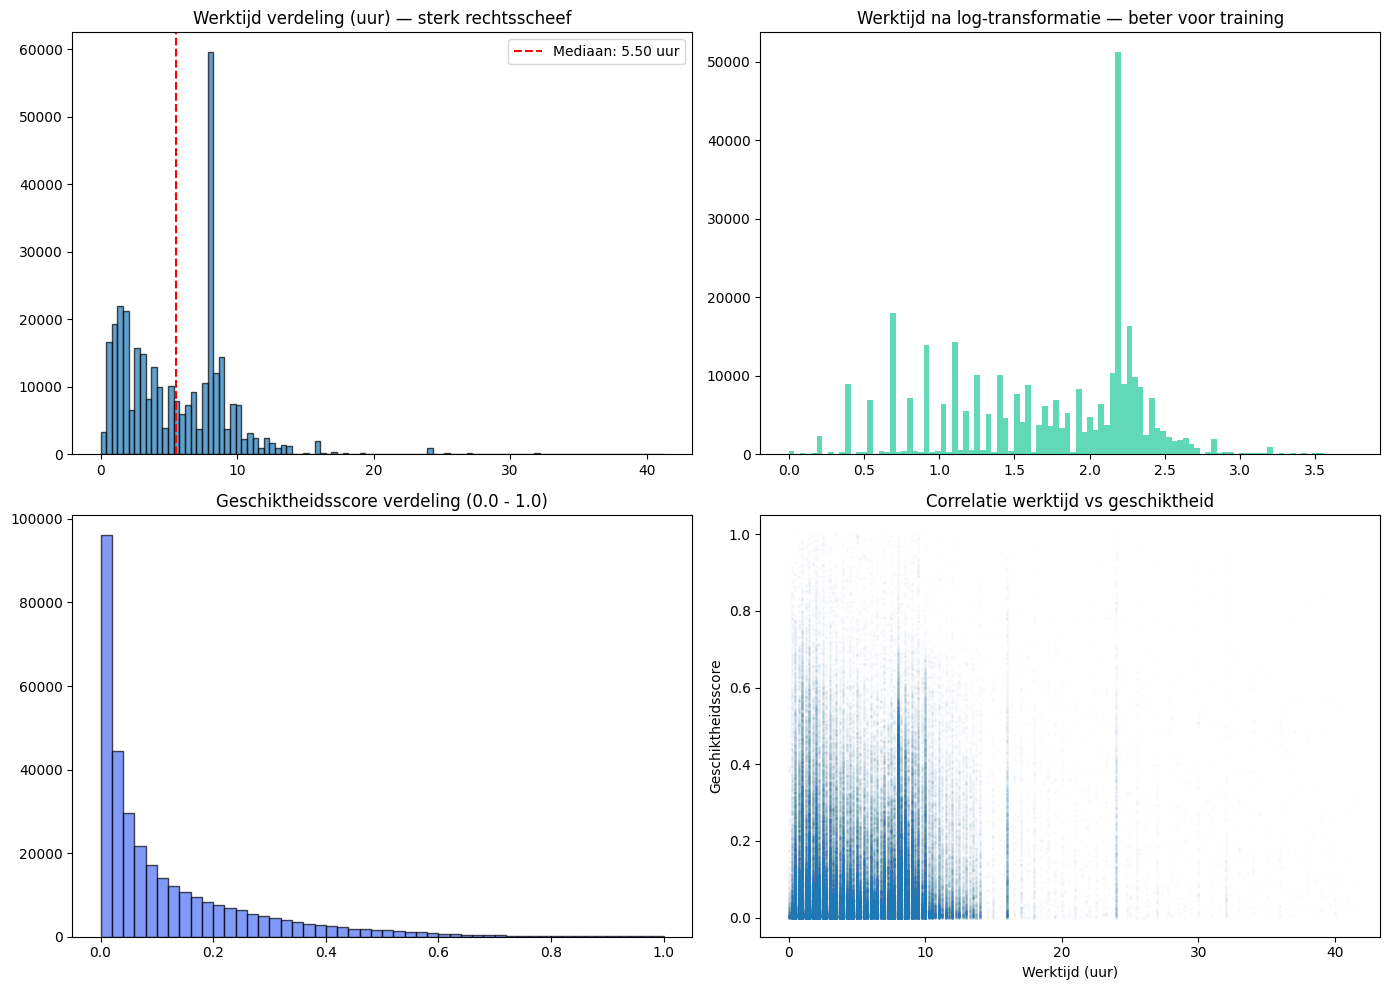

Correlatie werktijd-geschiktheid: 0.085
Lage correlatie => de twee taken hebben andere patronen => MMoE is zinvol


In [92]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df[TARGET_TIME], bins=100, edgecolor="black", alpha=0.7)
axes[0, 0].axvline(
    df[TARGET_TIME].median(),
    color="red",
    ls="--",
    label=f"Mediaan: {df[TARGET_TIME].median():.2f} uur",
)
axes[0, 0].set_title("Werktijd verdeling (uur) — sterk rechtsscheef")
axes[0, 0].legend()

axes[0, 1].hist(df["time_log"], bins=100, alpha=0.7, color="#20c997")
axes[0, 1].set_title("Werktijd na log-transformatie — beter voor training")

axes[1, 0].hist(df[TARGET_RANK], bins=50, edgecolor="black", alpha=0.7, color="#4c6ef5")
axes[1, 0].set_title("Geschiktheidsscore verdeling (0.0 - 1.0)")

axes[1, 1].scatter(df[TARGET_TIME], df[TARGET_RANK], alpha=0.01, s=2)
axes[1, 1].set_xlabel("Werktijd (uur)")
axes[1, 1].set_ylabel("Geschiktheidsscore")
axes[1, 1].set_title("Correlatie werktijd vs geschiktheid")

plt.tight_layout()
plt.show()

corr = df[[TARGET_TIME, TARGET_RANK]].corr().iloc[0, 1]
print(f"Correlatie werktijd-geschiktheid: {corr:.3f}")
print("Lage correlatie => de twee taken hebben andere patronen => MMoE is zinvol")

## Stap 8: Dataset en DataLoader

PyTorch werkt met een `Dataset` klasse die bepaalt hoe data wordt aangeboden, en een `DataLoader` die data in **batches** levert.

**Wat is een batch?** In plaats van het model één rij tegelijk te laten leren, geven we het een groepje rijen tegelijk (bijv. 512). Dat is sneller en zorgt voor stabielere gradients.

Onze `RisterDataset` levert per rij:
- `cat` — integer codes voor categorische features (voor embedding lookup)
- `num` — genormaliseerde numerieke features
- `time` — log-getransformeerde werktijd
- `rank` — geschiktheidsscore

In [93]:
class RisterDataset(Dataset):
    """PyTorch Dataset voor Rister servicebezoeken."""

    def __init__(
        self, df_subset, num_scaled, cat_cols, target_time_col, target_rank_col
    ):
        self.cat = torch.tensor(
            df_subset[[c + "_enc" for c in cat_cols]].values, dtype=torch.long
        )
        self.num = torch.tensor(num_scaled, dtype=torch.float32)
        self.time = torch.tensor(df_subset[target_time_col].values, dtype=torch.float32)
        self.rank = torch.tensor(df_subset[target_rank_col].values, dtype=torch.float32)

    def __len__(self):
        return len(self.cat)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.time[idx], self.rank[idx]

### Train/validatie split en DataLoaders
80% van de data voor training, 20% voor validatie.

In [94]:
train_idx, val_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42
)

train_dataset = RisterDataset(
    df.iloc[train_idx].reset_index(drop=True),
    df_num_scaled[train_idx],
    CATEGORICAL,
    "time_log",
    TARGET_RANK,
)
val_dataset = RisterDataset(
    df.iloc[val_idx].reset_index(drop=True),
    df_num_scaled[val_idx],
    CATEGORICAL,
    "time_log",
    TARGET_RANK,
)

BATCH_SIZE = 512
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}")
print(f"Batch size: {BATCH_SIZE}  |  Train batches: {len(train_loader)}")

Train: 267,195  |  Val: 66,799
Batch size: 512  |  Train batches: 522


## Stap 9: MMoE Architectuur

### Hoe werkt het model stap voor stap?

**1 — Embedding laag**  
Elke categorische waarde (bijv. medewerker-ID 247) wordt omgezet naar een leerbare vector van getallen. Het model leert zelf wat de beste representatie is per categorie.

**2 — Expert netwerken**  
N kleine MLP-netwerken die elk hun eigen transformatie van de input leren. De ene expert leert misschien tijdspatronen, de andere medewerker-klant combinaties.

**3 — Gates**  
Per taak een gate die leert hoe zwaar elk expert meeweegt. Output is een softmax-verdeling over de experts (alles optelt tot 1.0).

**4 — Tower netwerken**  
Taak-specifieke netwerken die de gewogen expert-combinatie omzetten naar de uiteindelijke voorspelling.

**MLP** = Multi-Layer Perceptron, de basisvorm van een neuraal netwerk: opeenvolgende lineaire transformaties met een activeringsfunctie ertussen.

In [95]:
def make_mlp(in_dim, hidden_dims, out_dim, dropout):
    """Linear -> BatchNorm -> ReLU -> Dropout stapelen tot een MLP."""
    layers, prev = [], in_dim
    for h in hidden_dims:
        layers += [
            nn.Linear(prev, h),
            nn.BatchNorm1d(h),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]
        prev = h
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

### MMoEModel — `__init__`: embeddings, experts, gates, towers bouwen

### MMoEModel — `forward`: embeddings → experts → gates → towers

In [96]:
class MMoEModel(nn.Module):
    """
    Multi-gate Mixture of Experts voor Rister planning.
    Twee outputs: time_pred (log-uren) en rank_pred (0-1 geschiktheid).
    """

    def __init__(
        self,
        cat_cardinalities,
        num_features,
        emb_dim=8,
        n_experts=4,
        expert_dim=256,
        expert_layers=None,
        tower_layers=None,
        dropout=0.2,
    ):
        super().__init__()
        expert_layers = expert_layers or [256, 256]
        tower_layers = tower_layers or [128]

        # Embedding tabel per categorische feature (+1 voor onbekende waarde)
        self.embeddings = nn.ModuleList(
            [nn.Embedding(card + 1, emb_dim) for card in cat_cardinalities.values()]
        )
        input_dim = len(cat_cardinalities) * emb_dim + num_features
        self.input_dropout = nn.Dropout(dropout * 0.5)

        # N experts: elk leert zijn eigen representatie van de input
        self.experts = nn.ModuleList(
            [
                make_mlp(input_dim, expert_layers, expert_dim, dropout)
                for _ in range(n_experts)
            ]
        )

        # Gates: één per taak, leert welke experts zwaar wegen
        self.gate_time = nn.Linear(input_dim, n_experts)
        self.gate_rank = nn.Linear(input_dim, n_experts)

        # Towers: taak-specifieke lagen na de expert-mix
        self.tower_time = make_mlp(expert_dim, tower_layers, 1, dropout)
        self.tower_rank = make_mlp(expert_dim, tower_layers, 1, dropout)
        self.n_experts = n_experts

    def forward(self, cat, num):
        # 1. Embeddings samenvoegen met numerieke features
        embs = [emb(cat[:, j]) for j, emb in enumerate(self.embeddings)]
        x = self.input_dropout(torch.cat(embs + [num], dim=1))

        # 2. Experts: (batch, n_experts, expert_dim)
        E = torch.stack([expert(x) for expert in self.experts], dim=1)

        # 3. Gates: softmax = verdeling die optelt tot 1.0
        w_time = F.softmax(self.gate_time(x), dim=1).unsqueeze(-1)
        w_rank = F.softmax(self.gate_rank(x), dim=1).unsqueeze(-1)

        # 4. Gewogen som van experts per taak
        mix_time = (w_time * E).sum(dim=1)
        mix_rank = (w_rank * E).sum(dim=1)

        # 5. Towers naar output
        time_pred = self.tower_time(mix_time).squeeze(1)
        rank_pred = torch.sigmoid(self.tower_rank(mix_rank).squeeze(1))
        return time_pred, rank_pred

### Parametercheck
Even controleren hoeveel trainbare parameters het model heeft.

In [97]:
test_model = MMoEModel(cat_cardinalities=cat_cardinalities, num_features=len(NUMERICAL))
total_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"MMoE model: {total_params:,} trainbare parameters")
del test_model

MMoE model: 846,578 trainbare parameters


## Stap 10: Loss functie

De **loss** meet hoe ver de voorspelling afzit van de werkelijkheid. Hoe lager, hoe beter.

We gebruiken een gecombineerde loss:
```
total_loss = alpha * time_loss + (1 - alpha) * rank_loss
```

- **Huber loss** voor tijdsvoorspelling — robuust voor uitschieters (extreme lange taken)
- **Binary Cross-Entropy** voor ranking — geschikt voor scores tussen 0 en 1
- **alpha** bepaalt hoe zwaar elke taak meeweegt (instelbaar via Optuna)

In [98]:
def compute_loss(time_pred, rank_pred, time_true, rank_true, alpha=0.5):
    """
    Gecombineerde loss voor tijdsvoorspelling + ranking.

    alpha = 0.5  ->  gelijke weging
    alpha = 0.7  ->  tijdsvoorspelling zwaarder
    alpha = 0.3  ->  ranking zwaarder
    """
    # Huber: werkt als MSE voor kleine fouten, als MAE voor grote fouten
    time_loss = F.huber_loss(time_pred, time_true, delta=1.0)

    # BCE: standaard loss voor output tussen 0 en 1
    rank_loss = F.binary_cross_entropy(rank_pred, rank_true.clamp(0, 1))

    total = alpha * time_loss + (1.0 - alpha) * rank_loss
    return total, time_loss, rank_loss


print("Loss functie gedefinieerd.")
print("  Tijdscomponent   : Huber loss")
print("  Rankingcomponent : Binary Cross-Entropy")
print("  Combinatie       : alpha * tijd + (1-alpha) * ranking")

Loss functie gedefinieerd.
  Tijdscomponent   : Huber loss
  Rankingcomponent : Binary Cross-Entropy
  Combinatie       : alpha * tijd + (1-alpha) * ranking


## Stap 11: Hyperparameter optimalisatie met Optuna

**Hyperparameters** zijn instellingen die je vóór de training kiest, zoals het aantal experts, de leersnelheid en de dropout. Het model leert deze niet zelf.

**Optuna** zoekt automatisch de beste combinatie:
1. Kies een combinatie (bijv. 4 experts, lr=0.001)
2. Train een mini-model voor 15 epochs
3. Meet de validatie-MAE
4. Gebruik die info voor een betere volgende combinatie
5. Herhaal N keer

**Pruning**: slechte trials stoppen vroeg zodat we tijd besparen.

De `objective` functie is los gedefinieerd zodat Optuna én de MLflow-check er allebei gebruik van kunnen maken.

In [99]:
optuna.logging.set_verbosity(optuna.logging.WARNING)


def build_trial_model(params):
    """Maak MMoE model op basis van Optuna trial params."""
    return MMoEModel(
        cat_cardinalities=cat_cardinalities,
        num_features=len(NUMERICAL),
        emb_dim=params["emb_dim"],
        n_experts=params["n_experts"],
        expert_dim=params["expert_dim"],
        expert_layers=[params["expert_hidden"]] * 2,
        tower_layers=[params["tower_hidden"]],
        dropout=params["dropout"],
    ).to(DEVICE)


def val_mae_on_loader(model):
    """Bereken validatie MAE in uren op de globale val_loader."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for cat_b, num_b, time_b, _ in val_loader:
            tp, _ = model(cat_b.to(DEVICE), num_b.to(DEVICE))
            preds.append(np.expm1(tp.cpu().numpy()))
            trues.append(np.expm1(time_b.numpy()))
    return mean_absolute_error(np.concatenate(trues), np.concatenate(preds))

### Optuna objective functie
Eén trial: bouw model, train 15 epochs met early stopping, geef val MAE terug.

In [100]:
OPTUNA_PARAM_SPACE = {
    "n_experts": lambda t: t.suggest_int("n_experts", 2, 8),
    "expert_dim": lambda t: t.suggest_categorical("expert_dim", [128, 256, 512]),
    "expert_hidden": lambda t: t.suggest_categorical("expert_hidden", [128, 256, 512]),
    "tower_hidden": lambda t: t.suggest_categorical("tower_hidden", [64, 128, 256]),
    "emb_dim": lambda t: t.suggest_categorical("emb_dim", [4, 8, 16]),
    "dropout": lambda t: t.suggest_float("dropout", 0.1, 0.4),
    "lr": lambda t: t.suggest_float("lr", 1e-4, 1e-2, log=True),
    "weight_decay": lambda t: t.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
    "alpha": lambda t: t.suggest_float("alpha", 0.3, 0.7),
}


def objective(trial):
    params = {k: fn(trial) for k, fn in OPTUNA_PARAM_SPACE.items()}
    m = build_trial_model(params)
    optimizer = torch.optim.AdamW(
        m.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    best_mae, patience_ctr = float("inf"), 0

    with mlflow.start_run(run_name=f"mmoe_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        for epoch in range(15):
            m.train()
            for cat_b, num_b, time_b, rank_b in train_loader:
                cat_b, num_b = cat_b.to(DEVICE), num_b.to(DEVICE)
                time_b, rank_b = time_b.to(DEVICE), rank_b.to(DEVICE)
                optimizer.zero_grad()
                tp, rp = m(cat_b, num_b)
                loss, _, _ = compute_loss(tp, rp, time_b, rank_b, params["alpha"])
                loss.backward()
                torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                optimizer.step()
            scheduler.step()
            mae = val_mae_on_loader(m)
            best_mae, patience_ctr = (
                (mae, 0) if mae < best_mae else (best_mae, patience_ctr + 1)
            )
            if patience_ctr >= 5:
                break
            trial.report(mae, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        mlflow.log_metric("val_mae", best_mae)
    return best_mae

### MLflow check — bestaande resultaten laden
Als er al trials zijn gedraaid, laden we de beste params direct. Anders starten we Optuna.

In [101]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name(MLFLOW_EXPERIMENT)

existing_runs = []
if experiment:
    existing_runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="tags.mlflow.runName LIKE 'mmoe_trial_%'",
        order_by=["metrics.val_mae ASC"],
        max_results=1,
    )

if existing_runs:
    p = existing_runs[0].data.params
    best_params = {
        "n_experts": int(p["n_experts"]),
        "expert_dim": int(p["expert_dim"]),
        "expert_hidden": int(p["expert_hidden"]),
        "tower_hidden": int(p["tower_hidden"]),
        "emb_dim": int(p["emb_dim"]),
        "dropout": float(p["dropout"]),
        "lr": float(p["lr"]),
        "weight_decay": float(p["weight_decay"]),
        "alpha": float(p["alpha"]),
    }
    print(
        f"Eerdere params geladen. Beste val MAE: {existing_runs[0].data.metrics['val_mae']:.4f} uur"
    )
    print(f"Params: {best_params}")
else:
    print("Geen eerdere runs gevonden — voer eerst de Optuna study cel hieronder uit.")

Eerdere params geladen. Beste val MAE: 1.6245 uur
Params: {'n_experts': 4, 'expert_dim': 512, 'expert_hidden': 256, 'tower_hidden': 128, 'emb_dim': 16, 'dropout': 0.13279605998901114, 'lr': 0.005940725152371348, 'weight_decay': 9.381958133121674e-05, 'alpha': 0.5492710017695336}


### Optuna study uitvoeren
Sla deze cel over als de cel hierboven al params heeft geladen.

In [102]:
if not existing_runs:
    print("Start Optuna zoektocht (40 trials)...")
    with mlflow.start_run(run_name="optuna_mmoe"):
        study = optuna.create_study(
            direction="minimize",
            study_name="mmoe_rister",
            pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
        )
        study.optimize(objective, n_trials=40, show_progress_bar=True)
    best_params = study.best_params
    print(f"Beste MAE: {study.best_value:.4f} uur ({study.best_value * 60:.1f} min)")
    print(f"Beste params: {best_params}")

## Stap 12: Volledig model trainen

Nu trainen we het volledige model met de beste hyperparameters. Dit keer met meer epochs.

**Epoch** = één complete doorloop van alle trainingsdata.

**Early stopping** stopt de training automatisch als de validatie-MAE N epochs lang niet verbetert. Dit voorkomt **overfitting**: het model kan de trainingsdata uit zijn hoofd leren maar presteert dan slecht op nieuwe data.

In [103]:
model = MMoEModel(
    cat_cardinalities=cat_cardinalities,
    num_features=len(NUMERICAL),
    emb_dim=best_params.get("emb_dim", 8),
    n_experts=best_params.get("n_experts", 4),
    expert_dim=best_params.get("expert_dim", 256),
    expert_layers=[best_params.get("expert_hidden", 256)] * 2,
    tower_layers=[best_params.get("tower_hidden", 128)],
    dropout=best_params.get("dropout", 0.2),
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_params.get("lr", 1e-3),
    weight_decay=best_params.get("weight_decay", 1e-4),
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
ALPHA = best_params.get("alpha", 0.5)
MAX_EPOCHS = 100
PATIENCE = 10
print(
    f"Model klaar | device: {DEVICE} | max {MAX_EPOCHS} epochs | early stopping: {PATIENCE}"
)

Model klaar | device: mps | max 100 epochs | early stopping: 10


### Training loop
Train het model epoch voor epoch. Na elke epoch meten we de val MAE. Als die `PATIENCE` keer niet verbetert, stoppen we vroeg.

In [104]:
train_losses, val_maes = [], []
best_val_mae = float("inf")
patience_ctr = 0
best_state = None

with mlflow.start_run(run_name="mmoe_final_training"):
    mlflow.log_params(best_params)

    for epoch in range(MAX_EPOCHS):
        # --- Train ---
        model.train()
        epoch_loss = 0.0
        for cat_b, num_b, time_b, rank_b in train_loader:
            cat_b, num_b = cat_b.to(DEVICE), num_b.to(DEVICE)
            time_b, rank_b = time_b.to(DEVICE), rank_b.to(DEVICE)
            optimizer.zero_grad()
            tp, rp = model(cat_b, num_b)
            loss, _, _ = compute_loss(tp, rp, time_b, rank_b, ALPHA)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        train_losses.append(epoch_loss / len(train_loader))

        # --- Valideer ---
        val_mae = val_mae_on_loader(model)
        val_maes.append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            patience_ctr = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        mlflow.log_metrics(
            {"train_loss": train_losses[-1], "val_mae": val_mae}, step=epoch
        )
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1:3d} | loss: {train_losses[-1]:.4f} | "
                f"val MAE: {val_mae:.4f}u ({val_mae * 60:.1f}min) | beste: {best_val_mae:.4f}"
            )
        if patience_ctr >= PATIENCE:
            print(f"Early stopping na epoch {epoch + 1}.")
            break

    model.load_state_dict(best_state)
    print(
        f"\nTraining klaar. Beste val MAE: {best_val_mae:.4f} uur ({best_val_mae * 60:.1f} min)"
    )
    mlflow.log_metric("best_val_mae", best_val_mae)

Epoch  10 | loss: 0.1681 | val MAE: 1.8092u (108.5min) | beste: 1.6672
Epoch  20 | loss: 0.1612 | val MAE: 1.8326u (110.0min) | beste: 1.6113
Epoch  30 | loss: 0.1569 | val MAE: 1.6145u (96.9min) | beste: 1.5992
Epoch  40 | loss: 0.1543 | val MAE: 1.6034u (96.2min) | beste: 1.5827
Epoch  50 | loss: 0.1532 | val MAE: 1.5852u (95.1min) | beste: 1.5775
Early stopping na epoch 56.

Training klaar. Beste val MAE: 1.5775 uur (94.7 min)
🏃 View run mmoe_final_training at: http://127.0.0.1:5001/#/experiments/3/runs/fdca3c706ac0421b82e5ac44ec2c1836
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


## Stap 13: Evaluatie — Tijdsvoorspelling

We meten:
- **MAE** — gemiddelde absolute fout in uren (hoofdmetric, KPI <= 30 min)
- **RMSE** — bestraft grote fouten zwaarder dan MAE
- **R²** — hoeveel variantie het model verklaart (1.0 = perfect, 0.0 = nutteloos)

In [105]:
# Voorspellingen verzamelen over de volledige validatieset
model.eval()
all_time_pred, all_time_true = [], []
all_rank_pred, all_rank_true = [], []

with torch.no_grad():
    for cat_b, num_b, time_b, rank_b in val_loader:
        tp, rp = model(cat_b.to(DEVICE), num_b.to(DEVICE))
        all_time_pred.append(np.expm1(tp.cpu().numpy()))
        all_time_true.append(np.expm1(time_b.numpy()))
        all_rank_pred.append(rp.cpu().numpy())
        all_rank_true.append(rank_b.numpy())

y_pred_time = np.concatenate(all_time_pred)
y_true_time = np.concatenate(all_time_true)
y_pred_rank = np.concatenate(all_rank_pred)
y_true_rank = np.concatenate(all_rank_true)

### Metrics berekenen

In [106]:
mae = mean_absolute_error(y_true_time, y_pred_time)
rmse = np.sqrt(mean_squared_error(y_true_time, y_pred_time))
r2 = r2_score(y_true_time, y_pred_time)

print(f"MAE  : {mae:.4f} uur  ({mae * 60:.1f} min)")
print(f"RMSE : {rmse:.4f} uur")
print(f"R2   : {r2:.4f}")
print(
    f"KPI  : MAE {'<= 30 min OK' if mae * 60 <= 30 else '> 30 min, verbetering nodig'}"
)

MAE  : 1.5775 uur  (94.7 min)
RMSE : 2.5354 uur
R2   : 0.5551
KPI  : MAE > 30 min, verbetering nodig


### Visualisatie tijdsvoorspelling

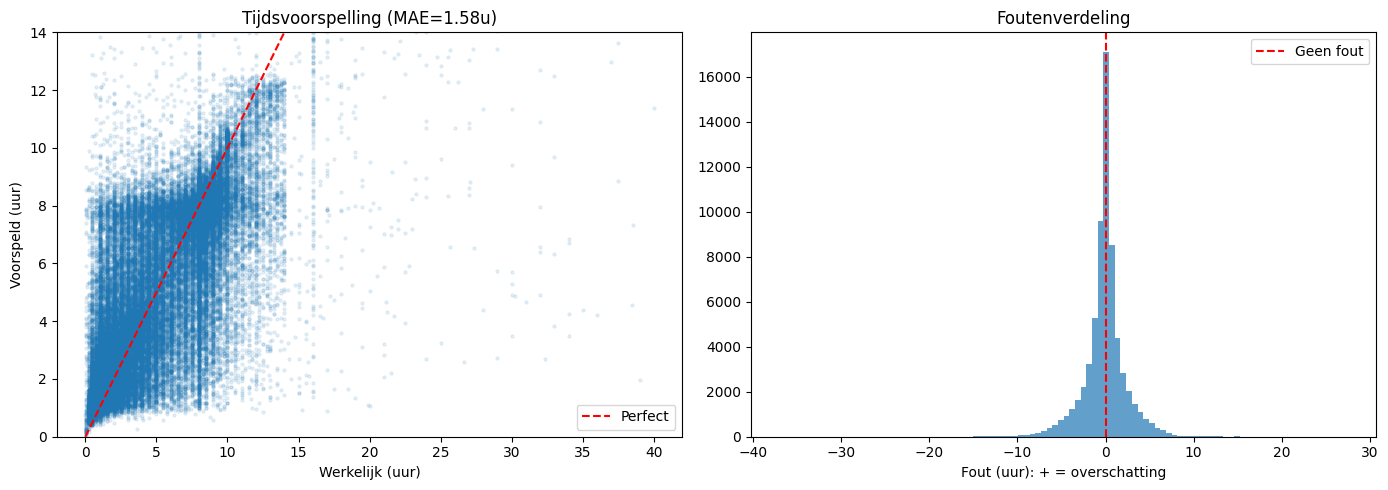

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_true_time, y_pred_time, alpha=0.1, s=5)
axes[0].plot([0, y_true_time.max()], [0, y_true_time.max()], "r--", label="Perfect")
axes[0].set(
    xlabel="Werkelijk (uur)",
    ylabel="Voorspeld (uur)",
    ylim=(0, 14),
    title=f"Tijdsvoorspelling (MAE={mae:.2f}u)",
)
axes[0].legend()

axes[1].hist(y_pred_time - y_true_time, bins=100, alpha=0.7)
axes[1].axvline(0, color="red", ls="--", label="Geen fout")
axes[1].set(title="Foutenverdeling", xlabel="Fout (uur): + = overschatting")
axes[1].legend()

plt.tight_layout()
plt.show()

## Stap 14: Evaluatie — Ranking

**NDCG** (Normalized Discounted Cumulative Gain) meet hoe goed de volgorde klopt:
- Fouten bovenin de lijst tellen zwaarder dan fouten onderaan
- NDCG@3 kijkt alleen naar de top 3 aanbevelingen
- NDCG = 1.0 is perfect

In [108]:
df_val = df.iloc[val_idx].reset_index(drop=True).copy()
df_val["rank_pred"] = y_pred_rank
df_val["_group_key"] = (
    df_val[["con", "BEWERKING_ID"]].astype(str).agg("__".join, axis=1)
)

ndcg3_scores, ndcg5_scores = [], []
for _, grp in df_val.groupby("_group_key"):
    if len(grp) < 2:
        continue
    ndcg3_scores.append(
        ndcg_score([grp[TARGET_RANK].values], [grp["rank_pred"].values], k=3)
    )
    ndcg5_scores.append(
        ndcg_score([grp[TARGET_RANK].values], [grp["rank_pred"].values], k=5)
    )

print(f"NDCG@3 : {np.mean(ndcg3_scores):.4f}")
print(f"NDCG@5 : {np.mean(ndcg5_scores):.4f}")

NDCG@3 : 0.9892
NDCG@5 : 0.9911


### Visualisatie ranking

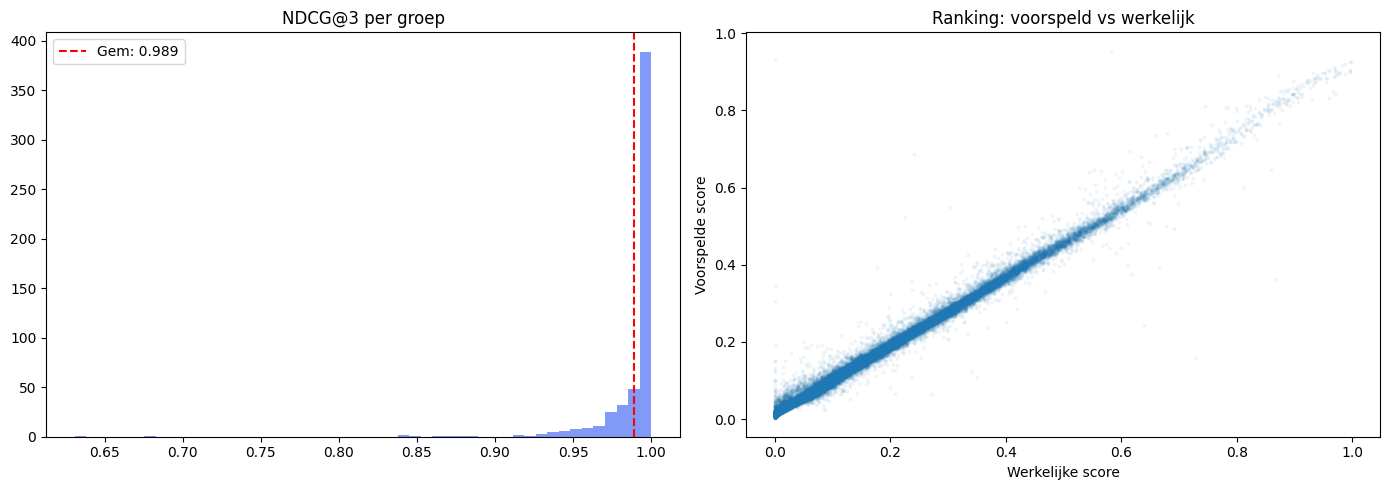

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ndcg3_scores, bins=50, alpha=0.7, color="#4c6ef5")
axes[0].axvline(
    np.mean(ndcg3_scores),
    color="red",
    ls="--",
    label=f"Gem: {np.mean(ndcg3_scores):.3f}",
)
axes[0].set(title="NDCG@3 per groep")
axes[0].legend()

axes[1].scatter(y_true_rank, y_pred_rank, alpha=0.05, s=3)
axes[1].set(
    xlabel="Werkelijke score",
    ylabel="Voorspelde score",
    title="Ranking: voorspeld vs werkelijk",
)

plt.tight_layout()
plt.show()

In [110]:
def prepare_batch(taak_row, medewerkers):
    """
    Bouw cat_tensor + num_tensor voor een batch medewerkers op dezelfde taak.
    Gedeeld door bereken_top_k_hit_rate en voorspel_per_medewerker.
    """
    batch_df = pd.DataFrame([{**taak_row, "URENVERANTW_MEDID": m} for m in medewerkers])

    cat_data = []
    for col in CATEGORICAL:
        vals = batch_df[col].fillna("ONBEKEND").astype(str).values
        known = set(label_encoders[col].classes_)
        enc = label_encoders[col].transform(
            [v if v in known else "ONBEKEND" for v in vals]
        )
        cat_data.append(enc)

    cat_t = torch.tensor(np.column_stack(cat_data), dtype=torch.long).to(DEVICE)
    num_t = torch.tensor(
        scaler.transform(
            batch_df[NUMERICAL].apply(pd.to_numeric, errors="coerce").fillna(0).values
        ),
        dtype=torch.float32,
    ).to(DEVICE)
    return cat_t, num_t

## Stap 15: Top-3 Hit Rate

De meest praktische metric: hoe vaak staat de werkelijk ingeplanste medewerker in de top 3 aanbevelingen?

Dit simuleert de echte situatie: de planner krijgt 3 kandidaten en kiest er één. Als de juiste persoon er altijd bij zit, werkt het systeem goed genoeg in de praktijk.

**KPI: >= 80% hit rate**

In [111]:
def bereken_top_k_hit_rate(model, df, val_idx, k=3, n_samples=500):
    """
    Simuleer de planningssituatie: scoor alle medewerkers per taak,
    check of de werkelijk ingeplanste medewerker in de top-K zit.
    """
    model.eval()
    hits, total = 0, 0
    sample_indices = np.random.choice(
        len(val_idx), min(n_samples, len(val_idx)), replace=False
    )

    for idx in sample_indices:
        row = df.iloc[val_idx[idx]]
        alle_meds = df.loc[df["con"] == row["con"], "URENVERANTW_MEDID"].unique()
        if len(alle_meds) < 2:
            continue
        cat_t, num_t = prepare_batch(row, alle_meds)
        with torch.no_grad():
            _, scores = model(cat_t, num_t)
        if row["URENVERANTW_MEDID"] in alle_meds[np.argsort(scores.cpu().numpy())[-k:]]:
            hits += 1
        total += 1

    return hits / total if total > 0 else 0, hits, total

### Top-3 hit rate berekenen

In [112]:
print("Top-3 hit rate berekenen...")
hit_rate, hits, total = bereken_top_k_hit_rate(model, df, val_idx)
print(f"Top-3 hit rate : {hits}/{total} = {hit_rate:.1%}")
print(f"KPI >= 80%     : {'OK' if hit_rate >= 0.80 else 'nog verbetering nodig'}")

Top-3 hit rate berekenen...


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWa

Top-3 hit rate : 48/500 = 9.6%
KPI >= 80%     : nog verbetering nodig


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Stap 16a: Trainingscurve

Laat zien hoe de train loss en validatie-MAE per epoch zijn veranderd.
Een gezonde curve daalt beide snel in het begin en stabiliseert — zonder grote kloof ertussen (kloof = overfitting).

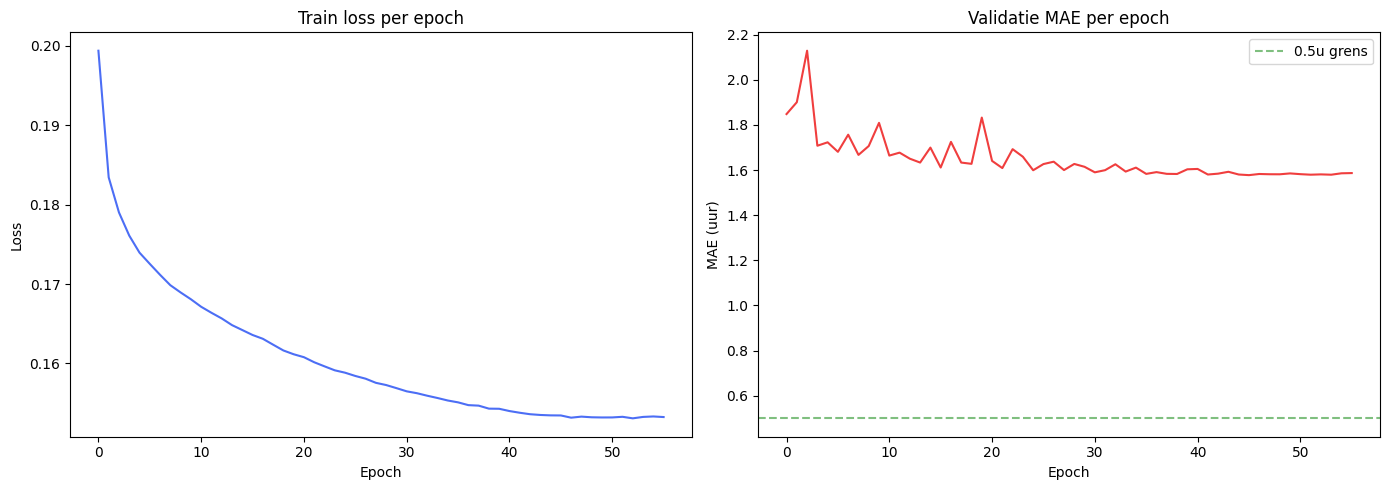

Beste val MAE bereikt in epoch: 46


In [113]:
# Trainingscurve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, color="#4c6ef5")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Train loss per epoch")

axes[1].plot(val_maes, color="#f03e3e")
axes[1].axhline(0.5, color="green", ls="--", alpha=0.5, label="0.5u grens")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (uur)")
axes[1].set_title("Validatie MAE per epoch")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Beste val MAE bereikt in epoch: {np.argmin(val_maes) + 1}")

## Stap 16b: Feature Importance via Permutatie

Neurale netwerken hebben geen ingebouwde feature importance zoals beslisbomen. We gebruiken **permutatie importance**:

1. Meet de baseline MAE op de validatieset
2. Shuffle één feature willekeurig — alle verbanden met die feature worden verbroken
3. Meet de nieuwe MAE
4. Verschil = hoe belangrijk die feature was

Grote MAE-stijging na shuffling = de feature was erg belangrijk voor het model.

In [114]:
def permutation_importance(model, val_loader, feature_names, n_cat, n_repeats=2):
    """Shuffle elke feature, meet MAE-stijging = belang van die feature."""
    baseline = val_mae_on_loader(model)
    importances = {}

    for fi, fname in enumerate(feature_names):
        maes = []
        for _ in range(n_repeats):
            p2, t2 = [], []
            model.eval()
            with torch.no_grad():
                for cat_b, num_b, time_b, _ in val_loader:
                    cb, nb_ = cat_b.clone(), num_b.clone()
                    perm = torch.randperm(cb.size(0))
                    if fi < n_cat:
                        cb[:, fi] = cb[perm, fi]
                    else:
                        nb_[:, fi - n_cat] = nb_[perm, fi - n_cat]
                    tp, _ = model(cb.to(DEVICE), nb_.to(DEVICE))
                    p2.append(np.expm1(tp.cpu().numpy()))
                    t2.append(np.expm1(time_b.numpy()))
            maes.append(mean_absolute_error(np.concatenate(t2), np.concatenate(p2)))
        importances[fname] = np.mean(maes) - baseline

    return importances, baseline

### Importance berekenen en visualiseren

Permutatie importance berekenen...


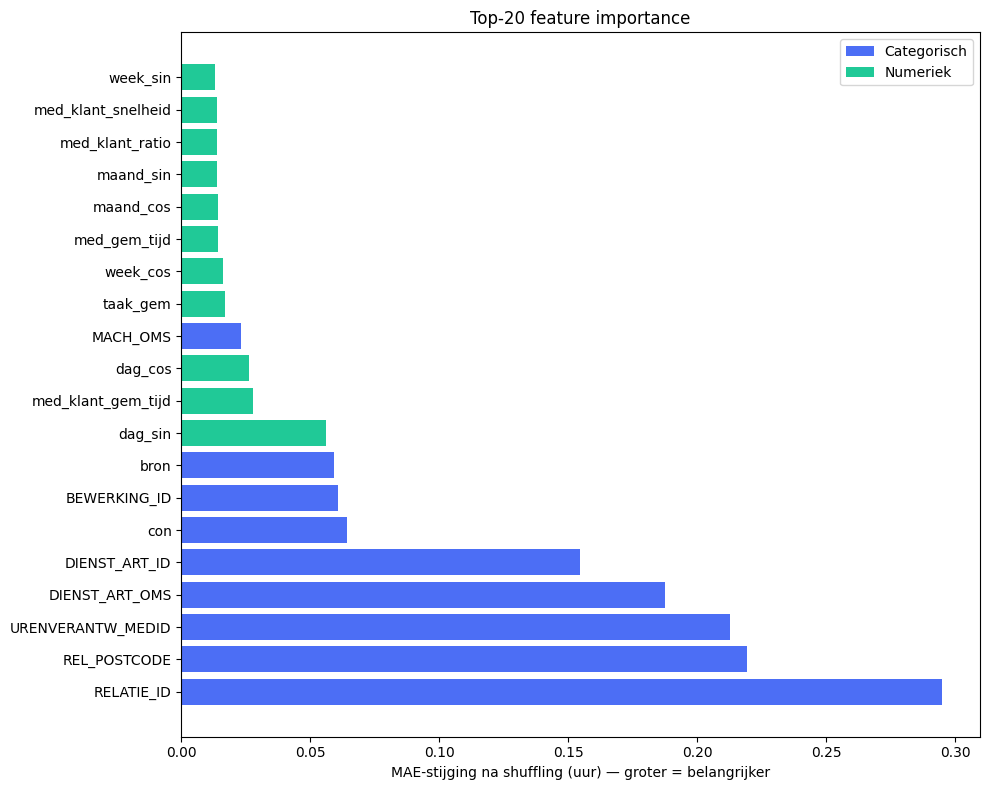


Top 10:
           feature  importance type
        RELATIE_ID    0.294803  cat
      REL_POSTCODE    0.219402  cat
 URENVERANTW_MEDID    0.212470  cat
    DIENST_ART_OMS    0.187331  cat
     DIENST_ART_ID    0.154431  cat
               con    0.064126  cat
      BEWERKING_ID    0.060827  cat
              bron    0.059170  cat
           dag_sin    0.056039  num
med_klant_gem_tijd    0.027698  num


In [115]:
print("Permutatie importance berekenen...")
importances, baseline_mae = permutation_importance(
    model, val_loader, CATEGORICAL + NUMERICAL, len(CATEGORICAL)
)

imp_df = pd.DataFrame(
    [
        {"feature": k, "importance": v, "type": "cat" if k in CATEGORICAL else "num"}
        for k, v in importances.items()
    ]
).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#4c6ef5" if t == "cat" else "#20c997" for t in imp_df.head(20)["type"]]
ax.barh(imp_df.head(20)["feature"], imp_df.head(20)["importance"], color=colors)
ax.set_xlabel("MAE-stijging na shuffling (uur) — groter = belangrijker")
ax.set_title("Top-20 feature importance")
ax.legend(
    handles=[
        Patch(facecolor="#4c6ef5", label="Categorisch"),
        Patch(facecolor="#20c997", label="Numeriek"),
    ]
)
plt.tight_layout()
plt.show()

print("\nTop 10:")
print(imp_df.head(10).to_string(index=False))

## Stap 17: Fine-tuning per database

Het basismodel is getraind op alle klanten samen. Sommige klanten hebben specifieke patronen. **Fine-tuning** past het model per klant aan:

1. Laad het basismodel
2. **Bevries** alle lagen behalve de towers (shared kennis behouden)
3. Train nog 20 epochs op klant-specifieke data

Zo combineert het model algemene én klant-specifieke kennis.

In [116]:
def _maak_ft_model(best_params):
    """Kopieer basismodel, bevries alles behalve de towers."""
    ft = MMoEModel(
        cat_cardinalities=cat_cardinalities,
        num_features=len(NUMERICAL),
        emb_dim=best_params.get("emb_dim", 8),
        n_experts=best_params.get("n_experts", 4),
        expert_dim=best_params.get("expert_dim", 256),
        expert_layers=[best_params.get("expert_hidden", 256)] * 2,
        tower_layers=[best_params.get("tower_hidden", 128)],
        dropout=best_params.get("dropout", 0.2),
    ).to(DEVICE)
    ft.load_state_dict(model.state_dict())
    for name, param in ft.named_parameters():
        param.requires_grad = "tower" in name
    return ft

In [117]:
def _run_epoch(m, loader, optimizer=None):
    """Train (met optimizer) of valideer (zonder). Geeft MAE in uren terug."""
    training = optimizer is not None
    m.train(training)
    preds, trues = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for cb, nb_, tb, rb in loader:
            cb, nb_, tb, rb = (
                cb.to(DEVICE),
                nb_.to(DEVICE),
                tb.to(DEVICE),
                rb.to(DEVICE),
            )
            if training:
                optimizer.zero_grad()
            tp, rp = m(cb, nb_)
            loss, _, _ = compute_loss(tp, rp, tb, rb, ALPHA)
            if training:
                loss.backward()
                optimizer.step()
            preds.append(np.expm1(tp.detach().cpu().numpy()))
            trues.append(np.expm1(tb.cpu().numpy()))
    return mean_absolute_error(np.concatenate(trues), np.concatenate(preds))

### Fine-tuning loop

In [ ]:
def _maak_dataloader(idx, shuf):
    return DataLoader(
        RisterDataset(
            df.iloc[idx].reset_index(drop=True),
            scaler.transform(df.iloc[idx][NUMERICAL].fillna(0)),
            CATEGORICAL,
            "time_log",
            TARGET_RANK,
        ),
        batch_size=256,
        shuffle=shuf,
        num_workers=0,
    )

In [ ]:
finetuned_models = {}

for db_id in df["con"].unique():
    db_indices = df.index[df["con"] == db_id].values
    if len(db_indices) < 1000:
        print(f"{db_id}: te weinig data ({len(db_indices)} rijen), gebruikt basismodel")
        continue

    tr_idx, va_idx = train_test_split(db_indices, test_size=0.2, random_state=42)
    db_train_ld, db_val_ld = (
        _maak_dataloader(tr_idx, True),
        _maak_dataloader(va_idx, False),
    )

    ft = _maak_ft_model(best_params)
    ft_opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, ft.parameters()), lr=1e-4
    )
    best_ft_mae, best_ft_state = float("inf"), None

    for epoch in range(20):
        _run_epoch(ft, db_train_ld, optimizer=ft_opt)
        ft_mae = _run_epoch(ft, db_val_ld)
        if ft_mae < best_ft_mae:
            best_ft_mae = ft_mae
            best_ft_state = {k: v.clone() for k, v in ft.state_dict().items()}

    ft.load_state_dict(best_ft_state)
    finetuned_models[db_id] = ft
    print(f"{db_id}: {len(db_indices)} rijen, val MAE: {best_ft_mae:.4f} uur")

print(f"\nFine-tuned voor {len(finetuned_models)} databases.")

15_poel: 1627 rijen, val MAE: 0.8343 uur
18_westra: 1202 rijen, val MAE: 1.0143 uur
24_jennissen: 22303 rijen, val MAE: 1.4243 uur
23_jennissen: 20283 rijen, val MAE: 1.5017 uur
19_westra: 1810 rijen, val MAE: 1.0875 uur
20_westra: 7447 rijen, val MAE: 1.4976 uur
24_kuijpers: 16028 rijen, val MAE: 1.1002 uur
25_kuijpers: 13772 rijen, val MAE: 1.1924 uur
21_melse: 4964 rijen, val MAE: 0.9685 uur
22_westra: 9539 rijen, val MAE: 1.3256 uur
21_westra: 8912 rijen, val MAE: 1.4419 uur
22_melse: 7098 rijen, val MAE: 0.8952 uur
25_melse: 8805 rijen, val MAE: 1.0336 uur
24_melse: 6761 rijen, val MAE: 0.9351 uur
23_melse: 7489 rijen, val MAE: 0.9220 uur
21_jennissen: 20812 rijen, val MAE: 1.4133 uur
21_diepen: 6451 rijen, val MAE: 1.1063 uur
22_jennissen: 20959 rijen, val MAE: 1.4921 uur
22_poel: 1088 rijen, val MAE: 1.0515 uur
22_diepen: 6839 rijen, val MAE: 1.0296 uur
23_westra: 9078 rijen, val MAE: 1.3629 uur
23_diepen: 6923 rijen, val MAE: 1.1488 uur
23_derks: 9363 rijen, val MAE: 1.4196 uur

## Stap 18: Voorspellen — 'Wie moet ik inplannen?'

Dit is hoe de C# API het model straks gebruikt:
1. Er komt een taak binnen
2. Voor elke beschikbare medewerker maken we een rij aan
3. Het model scoort ze allemaal in één batch
4. De planner krijgt: verwachte duur + gesorteerde ranking

In [119]:
def voorspel_per_medewerker(model, taak_row, medewerkers):
    """Geef voor een taak een gesorteerde voorspelling per medewerker."""
    model.eval()
    cat_t, num_t = prepare_batch(taak_row, medewerkers)

    with torch.no_grad():
        tp, rp = model(cat_t, num_t)
        uren = np.expm1(tp.cpu().numpy()).clip(min=0)
        scores = rp.cpu().numpy()

    return (
        pd.DataFrame(
            {
                "medewerker": medewerkers,
                "verwachte_uren": uren.round(2),
                "geschiktheid": scores.round(3),
            }
        )
        .sort_values("geschiktheid", ascending=False)
        .reset_index(drop=True)
    )


# Voorbeeldvoorspelling
orig_idx = val_idx[np.random.randint(len(val_idx))]
row = df.iloc[orig_idx]
db_id = row["con"]
alle_meds = df.loc[df["con"] == db_id, "URENVERANTW_MEDID"].unique()
actief_model = finetuned_models.get(db_id, model)

resultaat = voorspel_per_medewerker(actief_model, row, alle_meds)

print(f"Opdracht index {orig_idx}  (database: {db_id})")
print(f"Werkelijke medewerker : {row['URENVERANTW_MEDID']}")
print(f"Werkelijke tijd       : {row[TARGET_TIME]:.2f} uur")
print("\nTop 10 aanbevelingen:")
print(resultaat.head(10).to_string(index=False))

Opdracht index 294162  (database: 25_jennissen)
Werkelijke medewerker : 132
Werkelijke tijd       : 8.00 uur

Top 10 aanbevelingen:
medewerker  verwachte_uren  geschiktheid
     10786            7.94         0.292
     10544            8.03         0.289
     10728            7.92         0.287
     10154            7.88         0.284
     10187            8.14         0.283
       117            7.73         0.283
     10203            8.40         0.283
     10372            8.07         0.282
       109            7.80         0.282
     10286            7.92         0.282


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Stap 19: Modellen opslaan

We slaan op:
- PyTorch model weights (`.pt`)
- LabelEncoders en Scaler (voor preprocessing van nieuwe data)
- Metadata JSON (feature lijsten, parameters, metrics)

In [120]:
os.makedirs("models", exist_ok=True)

torch.save(model.state_dict(), "models/mmoe_base.pt")
for db_id, ft_model in finetuned_models.items():
    torch.save(ft_model.state_dict(), f"models/mmoe_{db_id}.pt")
print(f"Model weights opgeslagen ({1 + len(finetuned_models)} bestanden)")

Model weights opgeslagen (40 bestanden)


### Preprocessing objecten opslaan
`LabelEncoders` en `StandardScaler` zijn nodig om nieuwe data op te verwerken bij inference.

In [121]:
with open("models/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Opgeslagen: label_encoders.pkl, scaler.pkl")

Opgeslagen: label_encoders.pkl, scaler.pkl


### Metadata opslaan
JSON met feature lijsten, parameters en metrics — gebruikt door de C# API.

In [122]:
metadata = {
    "categorical_features": CATEGORICAL,
    "numerical_features": NUMERICAL,
    "target_time": TARGET_TIME,
    "target_rank": TARGET_RANK,
    "cat_cardinalities": cat_cardinalities,
    "best_params": best_params,
    "finetuned_databases": list(finetuned_models.keys()),
    "metrics": {
        "val_mae_uren": float(mae),
        "val_mae_min": float(mae * 60),
        "val_rmse": float(rmse),
        "val_r2": float(r2),
        "ndcg_at_3": float(np.mean(ndcg3_scores)),
        "ndcg_at_5": float(np.mean(ndcg5_scores)),
        "top3_hit_rate": float(hit_rate),
    },
}
with open("models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)
print("Opgeslagen: metadata.json")

Opgeslagen: metadata.json


## Stap 20: ONNX Export

**ONNX** (Open Neural Network Exchange) is een universeel uitwisselformaat voor neurale netwerken. De C# API laadt dit via `Microsoft.ML.OnnxRuntime`.

Hoe werkt de export:
1. We geven het model een dummy-input
2. PyTorch registreert alle bewerkingen (trace)
3. Dit wordt opgeslagen als ONNX graph
4. We verifiëren dat ONNX en PyTorch dezelfde outputs geven

Het model krijgt twee inputs: `cat_input` (integers) en `num_input` (floats). Het geeft twee outputs: `time_pred` en `rank_pred`.

In [123]:
import onnxruntime as ort

os.makedirs("models_onnx", exist_ok=True)


def export_to_onnx(model, save_path, n_cat, n_num, device):
    """Exporteer MMoE model naar ONNX. Inputs: cat_input + num_input."""
    model.eval()
    model.cpu()
    torch.onnx.export(
        model,
        (torch.zeros(1, n_cat, dtype=torch.long), torch.zeros(1, n_num)),
        save_path,
        input_names=["cat_input", "num_input"],
        output_names=["time_pred", "rank_pred"],
        dynamic_axes={
            n: {0: "batch"}
            for n in ["cat_input", "num_input", "time_pred", "rank_pred"]
        },
        opset_version=17,
        verbose=False,
    )
    model.to(device)

### Basismodel en fine-tuned modellen exporteren

In [124]:
export_to_onnx(
    model, "models_onnx/mmoe_base.onnx", len(CATEGORICAL), len(NUMERICAL), DEVICE
)
print("Basismodel: models_onnx/mmoe_base.onnx")

for db_id, ft_model in finetuned_models.items():
    export_to_onnx(
        ft_model,
        f"models_onnx/mmoe_{db_id}.onnx",
        len(CATEGORICAL),
        len(NUMERICAL),
        DEVICE,
    )
    print(f"Fine-tuned: models_onnx/mmoe_{db_id}.onnx")

/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_42602/1444726114.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0326 09:36:52.097000 42602 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0326 09:36:52.914000 42602 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0326 09:36:52.

Applied 21 of general pattern rewrite rules.


/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_42602/1444726114.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0326 09:36:56.513000 42602 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


Basismodel: models_onnx/mmoe_base.onnx


W0326 09:36:57.393000 42602 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0326 09:36:57.395000 42602 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0326 09:36:57.397000 42602 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapp

...

Applied 21 of general pattern rewrite rules.
Fine-tuned: models_onnx/mmoe_f5ab1b29-de37-4818-bb05-b2fe57ce6768.onnx


/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_42602/1444726114.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0326 09:39:18.128000 42602 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0326 09:39:18.836000 42602 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0326 09:39:18.

Applied 21 of general pattern rewrite rules.
Fine-tuned: models_onnx/mmoe_863359ba-9560-4814-9fed-d1fe5cebcb39.onnx


W0326 09:39:22.786000 42602 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0326 09:39:22.788000 42602 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0326 09:39:22.789000 42602 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapp

Applied 21 of general pattern rewrite rules.
Fine-tuned: models_onnx/mmoe_e4809280-1fdc-4f0a-9842-bb8dc3f2e527.onnx


In [125]:
# Verificatie: PyTorch en ONNX moeten (bijna) identieke output geven
model.eval()
model.cpu()
test_cat, test_num = val_dataset.cat[:5], val_dataset.num[:5]

with torch.no_grad():
    pt_time, pt_rank = model(test_cat, test_num)
    pt_time, pt_rank = pt_time.numpy(), pt_rank.numpy()

sess = ort.InferenceSession("models_onnx/mmoe_base.onnx")
onnx_time, onnx_rank = sess.run(
    ["time_pred", "rank_pred"],
    {"cat_input": test_cat.numpy(), "num_input": test_num.numpy()},
)
model.to(DEVICE)

print(
    f"{'':>3}  {'PT tijd':>10}  {'ONNX tijd':>10}  {'PT rank':>10}  {'ONNX rank':>10}"
)
for i in range(5):
    print(
        f"{i:>3}  {pt_time[i]:>10.4f}  {onnx_time[i]:>10.4f}  {pt_rank[i]:>10.4f}  {onnx_rank[i]:>10.4f}"
    )
print(
    f"\nMax verschil tijd : {np.max(np.abs(pt_time - onnx_time)):.2e} (OK als < 1e-5)"
)
print(f"Max verschil rank : {np.max(np.abs(pt_rank - onnx_rank)):.2e}")

        PT tijd   ONNX tijd     PT rank   ONNX rank
  0      1.8648      1.8648      0.0838      0.0838
  1      1.9109      1.9109      0.0685      0.0685
  2      2.1862      2.1862      0.0182      0.0182
  3      0.7640      0.7640      0.0240      0.0240
  4      2.4157      2.4157      0.3382      0.3382

Max verschil tijd : 4.77e-07 (OK als < 1e-5)
Max verschil rank : 4.47e-08


### Category codes opslaan voor C# API
De C# API heeft een mapping nodig van label-string naar integer code.

In [126]:
cat_code_mapping = {
    col: {str(lbl): int(code) for code, lbl in enumerate(label_encoders[col].classes_)}
    for col in CATEGORICAL
}
with open("models/cat_codes.json", "w") as f:
    json.dump(cat_code_mapping, f, indent=2)
print("Opgeslagen: models/cat_codes.json")

Opgeslagen: models/cat_codes.json


## Stap 21: MLflow eindresultaten loggen

Alle metrics, parameters en modelbestanden registreren in MLflow voor vergelijking met toekomstige trainingsruns.

In [127]:
with mlflow.start_run(run_name="mmoe_final_results"):
    mlflow.log_params(best_params)
    mlflow.log_metrics(
        {
            "time_mae_uren": float(mae),
            "time_mae_min": float(mae * 60),
            "time_rmse": float(rmse),
            "time_r2": float(r2),
            "ndcg_at_3": float(np.mean(ndcg3_scores)),
            "ndcg_at_5": float(np.mean(ndcg5_scores)),
            "top3_hit_rate": float(hit_rate),
            "dataset_rows": len(df),
            "n_finetuned_dbs": len(finetuned_models),
        }
    )
    for path in [
        "models/mmoe_base.pt",
        "models/metadata.json",
        "models/cat_codes.json",
        "models_onnx/mmoe_base.onnx",
    ]:
        if os.path.exists(path):
            mlflow.log_artifact(path)

    print(f"Eindresultaten gelogd. Open: {MLFLOW_TRACKING_URI}")

Eindresultaten gelogd. Open: http://127.0.0.1:5001
🏃 View run mmoe_final_results at: http://127.0.0.1:5001/#/experiments/3/runs/600c223c50a04b21b47fcf4770be6510
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


In [129]:
client = MlflowClient()


def get_best_registry_mae(model_name):
    try:
        versions = client.get_latest_versions(model_name)
        maes = []
        for v in versions:
            metrics = client.get_run(v.run_id).data.metrics
            if "time_mae_uren" in metrics:
                maes.append(metrics["time_mae_uren"])
        return min(maes) if maes else float("inf")
    except Exception:
        return float("inf")  # Model bestaat nog niet → altijd registreren


best_mae_in_registry = get_best_registry_mae("rister-mmoe")

with mlflow.start_run(run_name="mmoe_final_results") as run:
    mlflow.log_params(best_params)
    mlflow.log_metrics(
        {
            "time_mae_uren": float(mae),
            "time_mae_min": float(mae * 60),
            # ... overige metrics ...
        }
    )

    # Model loggen zodat register_model werkt
    mlflow.pytorch.log_model(model, artifact_path="mmoe_model")

    # Overige artifacts
    for path in [
        "models/scaler.pkl",
        "models/cat_codes.json",
        "models_onnx/mmoe_base.onnx",
    ]:
        if os.path.exists(path):
            mlflow.log_artifact(path)

    run_id = run.info.run_id

# Registreren indien beter dan huidige beste versie
if mae < best_mae_in_registry:
    mlflow.register_model(f"runs:/{run_id}/mmoe_model", "rister-mmoe")
    print(
        f"Nieuwe beste versie geregistreerd! MAE: {mae:.4f} uur (was: {best_mae_in_registry:.4f})"
    )
else:
    print(
        f"Niet geregistreerd — huidige MAE ({mae:.4f}) is niet beter dan registry ({best_mae_in_registry:.4f})"
    )

/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_42602/2068152437.py:5: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  versions = client.get_latest_versions(model_name)
2026/03/26 10:26:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 10:26:48 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Successfully registered model 'rister-mmoe'.
202

🏃 View run mmoe_final_results at: http://127.0.0.1:5001/#/experiments/3/runs/0ca597a52aab4fb0b8a1debc3b7579b4
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3
Nieuwe beste versie geregistreerd! MAE: 1.5775 uur (was: inf)


Created version '1' of model 'rister-mmoe'.


## Stap 22: Eindoverzicht

Samenvatting van alle resultaten en opgeslagen bestanden.

In [ ]:
print("=" * 56)
print("  MMoE MODEL — EINDRESULTATEN")
print("=" * 56)
print("Architectuur")
print(f"  Experts       : {best_params.get('n_experts', 4)}")
print(f"  Expert dim    : {best_params.get('expert_dim', 256)}")
print(f"  Embedding dim : {best_params.get('emb_dim', 8)}")
print(f"  Dropout       : {best_params.get('dropout', 0.2):.2f}")
print()
print("Tijdsvoorspelling")
print(f"  MAE           : {mae:.3f} uur  ({mae * 60:.1f} min)")
print(f"  RMSE          : {rmse:.3f} uur")
print(f"  R2            : {r2:.4f}")
print(f"  KPI <= 30 min : {'OK' if mae * 60 <= 30 else 'Nog niet gehaald'}")
print()
print("Medewerker ranking")
print(f"  NDCG@3        : {np.mean(ndcg3_scores):.4f}")
print(f"  NDCG@5        : {np.mean(ndcg5_scores):.4f}")
print(f"  Top-3 hit rate: {hit_rate:.1%}")
print(f"  KPI >= 80%    : {'OK' if hit_rate >= 0.80 else 'Nog niet gehaald'}")
print()
print(f"Fine-tuning: {len(finetuned_models)} databases")
print()
print("Opgeslagen bestanden")
print("  models/mmoe_base.pt          PyTorch model weights")
print("  models_onnx/mmoe_base.onnx   ONNX voor C# API")
print("  models/cat_codes.json        Label encoding mapping")
print("  models/metadata.json         Feature en parameter info")
print("=" * 56)

  MMoE MODEL — EINDRESULTATEN
Architectuur
  Experts       : 4
  Expert dim    : 512
  Embedding dim : 16
  Dropout       : 0.13

Tijdsvoorspelling
  MAE           : 1.577 uur  (94.6 min)
  RMSE          : 2.531 uur
  R2            : 0.5567
  KPI <= 30 min : Nog niet gehaald

Medewerker ranking
  NDCG@3        : 0.9883
  NDCG@5        : 0.9899
  Top-3 hit rate: 11.4%
  KPI >= 80%    : Nog niet gehaald

Fine-tuning: 39 databases

Opgeslagen bestanden
  models/mmoe_base.pt          PyTorch model weights
  models_onnx/mmoe_base.onnx   ONNX voor C# API
  models/cat_codes.json        Label encoding mapping
  models/metadata.json         Feature en parameter info
